# 05 NESO Horizon Review: Reruns



## Cai thu vien

In [13]:
!pip install -q catboost xgboost lightgbm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Da cai va import xong.")


Da cai va import xong.


## Tai file `electricity_features_fixed.csv` len

In [14]:
from google.colab import files
uploaded = files.upload()
CSV_NAME = list(uploaded.keys())[0]
print("Da tai len:", CSV_NAME)


Saving electricity_features_fixed.csv to electricity_features_fixed (1).csv
Da tai len: electricity_features_fixed (1).csv


In [15]:
df = pd.read_csv(CSV_NAME)
df["DATETIME"] = pd.to_datetime(df["DATETIME"])
df = df.set_index("DATETIME").sort_index()
print("Shape:", df.shape)
df.head(3)


Shape: (104880, 25)


,ND,TSD,ENGLAND_WALES_DEMAND,ND_LAG_48,ND_LAG_336,SETTLEMENT_PERIOD,ND_ROLL_MEAN_48,ND_ROLL_STD_24,EMBEDDED_SOLAR_CAPACITY,ND_ROLL_STD_48,...,SOLAR_ROLL_MEAN_24,ND_LAG_36,PERIOD_COS,ND_LAG_24,ND_ROLL_STD_8,EMBEDDED_WIND_CAPACITY,SOLAR_ROLL_MEAN_8,DOW_SIN,IS_WEEKEND,DOW_COS
DATETIME,,,,,,,,,,,,,,,,,,,,,
2020-01-08 00:00:00,"22,751.0000","25,625.0000","21,366.0000","25,424.0000","26,340.0000",1,"33,176.1875","2,333.5146","13,042.0000","6,297.2861",...,298.9167,"27,669.0000",0.9914,"37,467.0000","1,765.6103","6,465.0000",38.8750,0.9749,0,-0.2225
2020-01-08 00:30:00,"23,123.0000","25,520.0000","21,795.0000","25,967.0000","26,921.0000",2,"33,145.8125","1,860.4485","13,042.0000","6,261.6481",...,298.9167,"30,571.0000",0.9659,"37,283.0000","1,479.2337","6,465.0000",11.1250,0.9749,0,-0.2225
2020-01-08 01:00:00,"22,990.0000","25,742.0000","21,641.0000","25,767.0000","26,569.0000",3,"33,112.5417","1,663.9013","13,042.0000","6,227.1747",...,298.9167,"33,850.0000",0.9239,"37,423.0000","1,167.5114","6,465.0000",0.8750,0.9749,0,-0.2225


## Chia tap va dinh nghia cot dac trung

Giong het quy uoc cua du an: Train 2020-2023, Validation 2024, Test 2025 (niem phong hoan
toan). Cot dac trung = tat ca cot TRU `ND` (muc tieu), `TSD`, `ENGLAND_WALES_DEMAND` (hai cot
"ho hang" cua muc tieu, khong dung lam dac trung).

In [16]:
TARGET = "ND"
NON_FEATURE_COLS = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]
feature_columns = [c for c in df.columns if c not in NON_FEATURE_COLS]
print(f"So dac trung: {len(feature_columns)}")
print(feature_columns)

train = df.loc[:"2023-12-31 23:30:00"]
valid = df.loc["2024-01-01":"2024-12-31 23:30:00"]
test = df.loc["2025-01-01":"2025-12-31 23:30:00"]

X_train, y_train = train[feature_columns], train[TARGET]
X_valid, y_valid = valid[feature_columns], valid[TARGET]
X_test, y_test = test[feature_columns], test[TARGET]

print(f"Train: {X_train.shape}   Valid: {X_valid.shape}   Test: {X_test.shape}")
assert len(test) == 17520, f"Canh bao: tap test co {len(test)} dong, khac 17520 nhu bao cao trong bai!"


So dac trung: 22
['ND_LAG_48', 'ND_LAG_336', 'SETTLEMENT_PERIOD', 'ND_ROLL_MEAN_48', 'ND_ROLL_STD_24', 'EMBEDDED_SOLAR_CAPACITY', 'ND_ROLL_STD_48', 'ND_ROLL_MEAN_8', 'ND_LAG_12', 'PERIOD_SIN', 'ND_ROLL_MEAN_24', 'SOLAR_ROLL_MEAN_48', 'SOLAR_ROLL_MEAN_24', 'ND_LAG_36', 'PERIOD_COS', 'ND_LAG_24', 'ND_ROLL_STD_8', 'EMBEDDED_WIND_CAPACITY', 'SOLAR_ROLL_MEAN_8', 'DOW_SIN', 'IS_WEEKEND', 'DOW_COS']
Train: (69792, 22)   Valid: (17568, 22)   Test: (17520, 22)


## Ham DM test

In [17]:
# Diebold-Mariano test cho 2 du bao co cung sai so ky vong hay khong
# (H0: hai model co loss trung binh bang nhau). power=2 -> squared error.
# Tra ve dm_statistic, p_value (2 phia, xap xi chuan), mean_loss_diff
# (duong = model 2 tot hon), n.
def diebold_mariano_test(y, yhat_1, yhat_2, power=2):
    y = np.asarray(y, dtype=float)
    e1 = y - np.asarray(yhat_1, dtype=float)
    e2 = y - np.asarray(yhat_2, dtype=float)
    loss1 = np.abs(e1) ** power
    loss2 = np.abs(e2) ** power
    d = loss1 - loss2
    n = len(d)
    d_bar = float(np.mean(d))
    var_d = float(np.var(d, ddof=0))
    dm_stat = d_bar / np.sqrt(var_d / n)
    from scipy import stats
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return {"dm_statistic": dm_stat, "p_value": p_value, "mean_loss_diff": d_bar, "n": n}

print("Da dinh nghia diebold_mariano_test().")


Da dinh nghia diebold_mariano_test().


## Phan A - Huan luyen lai 4 model va chay DM test cho 3 cap moi trong Bang 1

Dung dung sieu tham so da ghi trong `src/demandforecast/config.py` cua du an, de ket qua
tuong duong voi cac file `.pkl` da co (khong the tai file `.pkl` len Colab nen phai huan luyen
lai, nhung cung tham so + cung random_state = 42 nen ket qua se rat gan voi ban goc).

In [18]:
RANDOM_STATE = 42

print("Dang huan luyen CatBoost (~2-3 phut)...")
catboost_model = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=8, subsample=0.8,
    colsample_bylevel=0.8, random_state=RANDOM_STATE, early_stopping_rounds=50, verbose=False,
)
catboost_model.fit(X_train, y_train, eval_set=(X_valid, y_valid))
pred_catboost = catboost_model.predict(X_test)
print("Xong CatBoost.")

print("Dang huan luyen LightGBM (chua tuned)...")
lgbm_model = lgb.LGBMRegressor(
    objective="regression", n_estimators=1000, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1,
)
lgbm_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
               callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
pred_lgbm = lgbm_model.predict(X_test)
print("Xong LightGBM.")

print("Dang huan luyen LightGBM (Tuned)...")
lgbm_tuned_model = lgb.LGBMRegressor(
    objective="regression", n_estimators=1000, learning_rate=0.03, max_depth=6,
    num_leaves=63, subsample=0.9, colsample_bytree=0.7, min_child_samples=30,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
)
lgbm_tuned_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)],
                      callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
pred_lgbm_tuned = lgbm_tuned_model.predict(X_test)
print("Xong LightGBM (Tuned).")

print("Dang huan luyen XGBoost (Tuned)...")
xgb_tuned_model = xgb.XGBRegressor(
    objective="reg:squarederror", n_estimators=1000, learning_rate=0.03, max_depth=6,
    subsample=0.9, colsample_bytree=0.7, min_child_weight=5, random_state=RANDOM_STATE,
    n_jobs=-1, early_stopping_rounds=50,
)
xgb_tuned_model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
pred_xgb_tuned = xgb_tuned_model.predict(X_test)
print("Xong XGBoost (Tuned).")


Dang huan luyen CatBoost (~2-3 phut)...
Xong CatBoost.
Dang huan luyen LightGBM (chua tuned)...
Xong LightGBM.
Dang huan luyen LightGBM (Tuned)...
Xong LightGBM (Tuned).
Dang huan luyen XGBoost (Tuned)...
Xong XGBoost (Tuned).


In [19]:
def print_metrics(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = (np.abs((y_true - y_pred) / y_true)).mean() * 100
    print(f"{name:32s}  R2={r2:.4f}  MAE={mae:8.1f}  RMSE={rmse:8.1f}  MAPE={mape:.2f}%")
    return {"model": name, "R2": r2, "MAE": mae, "RMSE": rmse, "MAPE": mape}

print("Doi chieu voi Bang 1 cua bai (CatBoost: MAE 1192.4 / RMSE 1665.2 / MAPE 4.90 / R2 0.9272):")
_ = print_metrics("CatBoost Regressor", y_test, pred_catboost)
_ = print_metrics("LightGBM Regressor", y_test, pred_lgbm)
_ = print_metrics("LightGBM Regressor (Tuned)", y_test, pred_lgbm_tuned)
_ = print_metrics("XGBoost Regressor (Tuned)", y_test, pred_xgb_tuned)
print("\nNeu cac so tren lech nhieu so voi Bang 1 (vi du qua 1-2%), bao lai cho Claude truoc khi dung DM test ben duoi.")


Doi chieu voi Bang 1 cua bai (CatBoost: MAE 1192.4 / RMSE 1665.2 / MAPE 4.90 / R2 0.9272):
CatBoost Regressor                R2=0.9272  MAE=  1192.4  RMSE=  1665.2  MAPE=4.90%
LightGBM Regressor                R2=0.9229  MAE=  1230.8  RMSE=  1714.0  MAPE=5.01%
LightGBM Regressor (Tuned)        R2=0.9248  MAE=  1227.3  RMSE=  1693.2  MAPE=4.99%
XGBoost Regressor (Tuned)         R2=0.9239  MAE=  1229.6  RMSE=  1703.4  MAPE=5.04%

Neu cac so tren lech nhieu so voi Bang 1 (vi du qua 1-2%), bao lai cho Claude truoc khi dung DM test ben duoi.


In [20]:
pairs = [
    ("CatBoost Regressor", pred_catboost, "LightGBM Regressor (Tuned)", pred_lgbm_tuned),
    ("LightGBM Regressor (Tuned)", pred_lgbm_tuned, "XGBoost Regressor (Tuned)", pred_xgb_tuned),
    ("XGBoost Regressor (Tuned)", pred_xgb_tuned, "LightGBM Regressor", pred_lgbm),
]

dm_rows = []
for name_a, pred_a, name_b, pred_b in pairs:
    res = diebold_mariano_test(y_test.values, pred_a, pred_b)
    dm_rows.append({"model_a": name_a, "model_b": name_b, **res})
    print(f"{name_a}  vs  {name_b}")
    print(f"  DM stat = {res['dm_statistic']:.4f}   p = {res['p_value']:.6f}   "
          f"mean_loss_diff = {res['mean_loss_diff']:.2f}   n = {res['n']}\n")

dm_df = pd.DataFrame(dm_rows)
dm_df.to_csv("dm_tests_table1_tuned_pairs.csv", index=False)
dm_df


CatBoost Regressor  vs  LightGBM Regressor (Tuned)
  DM stat = -5.5579   p = 0.000000   mean_loss_diff = -94106.93   n = 17520

LightGBM Regressor (Tuned)  vs  XGBoost Regressor (Tuned)
  DM stat = -3.1203   p = 0.001806   mean_loss_diff = -34779.16   n = 17520

XGBoost Regressor (Tuned)  vs  LightGBM Regressor
  DM stat = -2.8686   p = 0.004122   mean_loss_diff = -36263.33   n = 17520



,model_a,model_b,dm_statistic,p_value,mean_loss_diff,n
0,CatBoost Regressor,LightGBM Regressor (Tuned),-5.5579,0.0000,"-94,106.9262",17520
1,LightGBM Regressor (Tuned),XGBoost Regressor (Tuned),-3.1203,0.0018,"-34,779.1619",17520
2,XGBoost Regressor (Tuned),LightGBM Regressor,-2.8686,0.0041,"-36,263.3321",17520


## Phan B - Chay lai ablation H2 / H3 / IS_WEEKEND

Huan luyen lai Random Forest, XGBoost (chua tuned), LightGBM (chua tuned) tren 4 tap dac trung:
day du, bo ma hoa gio trong ngay, bo ma hoa thu trong tuan, bo `IS_WEEKEND`. Mat khoang 5-10
phut vi huan luyen lai 3 model x 4 cau hinh = 12 lan.

In [21]:
def retrain_mae_without(model_name, feats):
    if model_name == "Random Forest Regressor":
        m = RandomForestRegressor(n_estimators=50, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
        m.fit(X_train[feats], y_train)
        yhat = m.predict(X_test[feats])
    elif model_name == "XGBoost Regressor":
        m = xgb.XGBRegressor(objective="reg:squarederror", n_estimators=1000, learning_rate=0.05,
                              max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                              early_stopping_rounds=50)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)], verbose=False)
        yhat = m.predict(X_test[feats])
    elif model_name == "LightGBM Regressor":
        m = lgb.LGBMRegressor(objective="regression", n_estimators=1000, learning_rate=0.05,
                               max_depth=8, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                               verbosity=-1)
        m.fit(X_train[feats], y_train, eval_set=[(X_valid[feats], y_valid)],
              callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)])
        yhat = m.predict(X_test[feats])
    else:
        raise ValueError(model_name)
    return mean_absolute_error(y_test, yhat)


MODELS_RQ2 = ["Random Forest Regressor", "XGBoost Regressor", "LightGBM Regressor"]
CONFIGS_RQ2 = {
    "All features": [],
    "Remove hour encoding (PERIOD_SIN/COS/SETTLEMENT_PERIOD)": ["PERIOD_SIN", "PERIOD_COS", "SETTLEMENT_PERIOD"],
    "Remove day-of-week encoding (DOW_SIN/COS)": ["DOW_SIN", "DOW_COS"],
    "Remove IS_WEEKEND": ["IS_WEEKEND"],
}

rows = []
for model_name in MODELS_RQ2:
    mae_full = None
    for cfg_name, drop_cols in CONFIGS_RQ2.items():
        feats = [c for c in feature_columns if c not in drop_cols]
        mae = retrain_mae_without(model_name, feats)
        if cfg_name == "All features":
            mae_full = mae
        pct = 0.0 if mae_full is None else (mae - mae_full) / mae_full * 100
        rows.append({"Model": model_name, "Config": cfg_name, "MAE": mae, "MAE change (%)": pct})
        print(f"{model_name:25s} | {cfg_name:55s} | MAE={mae:9.2f} | change={pct:+.2f}%")

rq2_df = pd.DataFrame(rows)
rq2_df.to_csv("hypothesis_h2h3_weekend_rerun.csv", index=False)
rq2_df


Random Forest Regressor   | All features                                            | MAE=  1332.88 | change=+0.00%
Random Forest Regressor   | Remove hour encoding (PERIOD_SIN/COS/SETTLEMENT_PERIOD) | MAE=  1352.82 | change=+1.50%
Random Forest Regressor   | Remove day-of-week encoding (DOW_SIN/COS)               | MAE=  1408.77 | change=+5.69%
Random Forest Regressor   | Remove IS_WEEKEND                                       | MAE=  1333.22 | change=+0.03%
XGBoost Regressor         | All features                                            | MAE=  1273.08 | change=+0.00%
XGBoost Regressor         | Remove hour encoding (PERIOD_SIN/COS/SETTLEMENT_PERIOD) | MAE=  1291.28 | change=+1.43%
XGBoost Regressor         | Remove day-of-week encoding (DOW_SIN/COS)               | MAE=  1331.39 | change=+4.58%
XGBoost Regressor         | Remove IS_WEEKEND                                       | MAE=  1235.43 | change=-2.96%
LightGBM Regressor        | All features                                

,Model,Config,MAE,MAE change (%)
0,Random Forest Regressor,All features,"1,332.8788",0.0000
1,Random Forest Regressor,Remove hour encoding (PERIOD_SIN/COS/SETTLEMEN...,"1,352.8224",1.4963
2,Random Forest Regressor,Remove day-of-week encoding (DOW_SIN/COS),"1,408.7671",5.6936
3,Random Forest Regressor,Remove IS_WEEKEND,"1,333.2166",0.0253
4,XGBoost Regressor,All features,"1,273.0789",0.0000
5,XGBoost Regressor,Remove hour encoding (PERIOD_SIN/COS/SETTLEMEN...,"1,291.2761",1.4294
6,XGBoost Regressor,Remove day-of-week encoding (DOW_SIN/COS),"1,331.3898",4.5803
7,XGBoost Regressor,Remove IS_WEEKEND,"1,235.4277",-2.9575
8,LightGBM Regressor,All features,"1,230.7858",0.0000
9,LightGBM Regressor,Remove hour encoding (PERIOD_SIN/COS/SETTLEMEN...,"1,270.0351",3.1890


## Phan C - Chan doan 4-panel cho CatBoost + kiem tra lai MAPE theo thang

Dung du bao CatBoost da co tu Phan A (`pred_catboost`), khong can huan luyen lai.

In [22]:
test_df = test.copy()
test_df["y_true"] = y_test.values
test_df["y_pred"] = pred_catboost
test_df["error"] = test_df["y_true"] - test_df["y_pred"]
test_df["ratio"] = test_df["y_pred"] / test_df["y_true"]

mape_year = (test_df["error"].abs() / test_df["y_true"]).mean() * 100
print(f"MAPE ca nam (CatBoost, tinh lai trong notebook nay): {mape_year:.2f}%  (Bang 1 cua bai bao cao 4.90%)")

monthly_mape = (
    test_df.assign(month=test_df.index.month)
    .groupby("month")
    .apply(lambda g: (g["error"].abs() / g["y_true"]).mean() * 100)
)
print("\nMAPE theo thang (CatBoost):")
print(monthly_mape.round(2))
print(f"\nThap nhat: {monthly_mape.min():.2f}%  (thang {monthly_mape.idxmin()})")
print(f"Cao nhat:  {monthly_mape.max():.2f}%  (thang {monthly_mape.idxmax()})")


MAPE ca nam (CatBoost, tinh lai trong notebook nay): 4.90%  (Bang 1 cua bai bao cao 4.90%)

MAPE theo thang (CatBoost):
month
1    3.8700
2    3.9900
3    5.7400
4    6.0000
5    6.3800
6    5.5600
7    4.5900
8    5.3400
9    5.1000
10   4.2400
11   3.8600
12   4.0800
dtype: float64

Thap nhat: 3.86%  (thang 11)
Cao nhat:  6.38%  (thang 5)


/tmp/ipykernel_1805/177729791.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g["error"].abs() / g["y_true"]).mean() * 100)


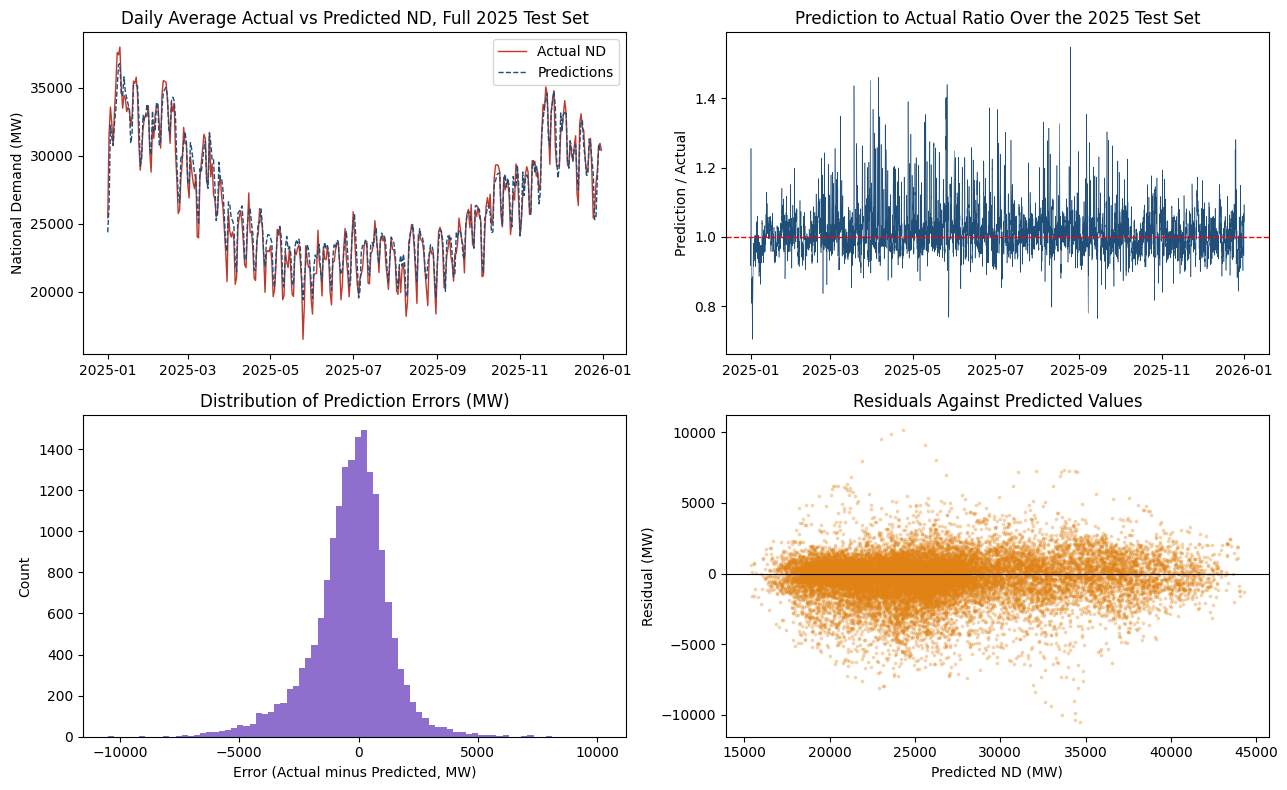

Da luu hinh: ml_performance_catboost.png


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

daily = test_df.resample("D").agg({"y_true": "mean", "y_pred": "mean"})
axes[0, 0].plot(daily.index, daily["y_true"], label="Actual ND", color="#C0392B", linewidth=1)
axes[0, 0].plot(daily.index, daily["y_pred"], label="Predictions", color="#1F4E79", linewidth=1, linestyle="--")
axes[0, 0].set_title("Daily Average Actual vs Predicted ND, Full 2025 Test Set")
axes[0, 0].set_ylabel("National Demand (MW)")
axes[0, 0].legend()

axes[0, 1].plot(test_df.index, test_df["ratio"], color="#1F4E79", linewidth=0.4)
axes[0, 1].axhline(1.0, color="red", linestyle="--", linewidth=1)
axes[0, 1].set_title("Prediction to Actual Ratio Over the 2025 Test Set")
axes[0, 1].set_ylabel("Prediction / Actual")

axes[1, 0].hist(test_df["error"], bins=80, color="#8E6FCE", edgecolor="none")
axes[1, 0].set_title("Distribution of Prediction Errors (MW)")
axes[1, 0].set_xlabel("Error (Actual minus Predicted, MW)")
axes[1, 0].set_ylabel("Count")

axes[1, 1].scatter(test_df["y_pred"], test_df["error"], s=3, alpha=0.25, color="#E08214")
axes[1, 1].axhline(0, color="black", linewidth=0.8)
axes[1, 1].set_title("Residuals Against Predicted Values")
axes[1, 1].set_xlabel("Predicted ND (MW)")
axes[1, 1].set_ylabel("Residual (MW)")

plt.tight_layout()
plt.savefig("ml_performance_catboost.png", dpi=300, bbox_inches="tight")
plt.show()
print("Da luu hinh: ml_performance_catboost.png")


## Tai file ket qua ve may

In [24]:
from google.colab import files
files.download("dm_tests_table1_tuned_pairs.csv")
files.download("hypothesis_h2h3_weekend_rerun.csv")
files.download("ml_performance_catboost.png")
print("Da tai ve xong ca 3 file")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Da tai ve xong ca 3 file
